# Practica ESPI

In [39]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

uint16


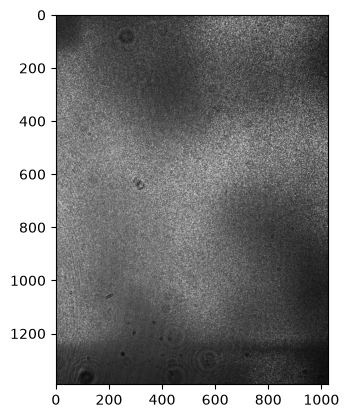

In [80]:
# metemos toodas las imagenes
ref1 = cv2.imread('Imagenes_ESPI/Sin sonido/pxfly_0007.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
print(ref1.dtype)
# Convertimos a float64
ref1 = np.float64(ref1)
plt.imshow(ref1, cmap='gray')

uint16


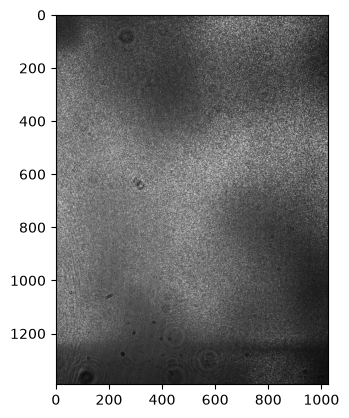

In [82]:
son1 = cv2.imread('Imagenes_ESPI/Con Sonido/pxfly_0001.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
print(son1.dtype)
son1 = np.float64(son1)
plt.imshow(son1, cmap='gray')

In [83]:
%load_ext autoreload
%autoreload 2

import sys
import os

# 2. Le decimos a Python que mire "una carpeta hacia atrás" (..) y entre a PCO_PixelFly
ruta_pco = os.path.abspath('../PCO_PixelFly')

if ruta_pco not in sys.path:
    sys.path.append(ruta_pco)
# Biblioteca propia
from procesamiento import filtros_en_frecuencia 
from procesamiento import operaciones_basicas


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


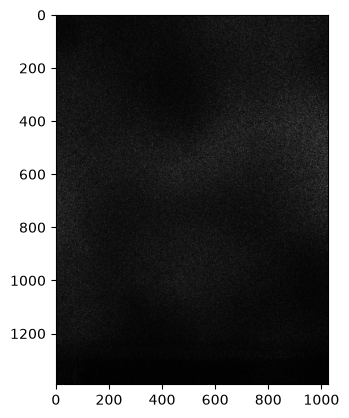

In [84]:
resta1 = operaciones_basicas.restar_consecutivas(ref1, son1)
plt.imshow(resta1, cmap='gray')

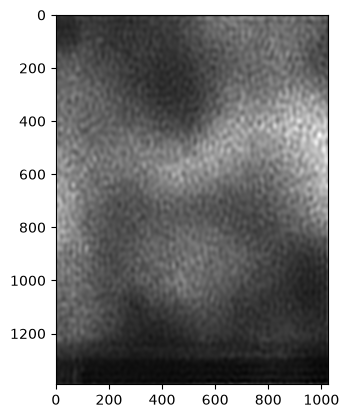

In [87]:
# Pasa bajas
Primero_filtrado = filtros_en_frecuencia.filtro_pasa_bajas_frecuencia(resta1, radio_corte=50)
plt.imshow(Primero_filtrado, cmap='gray')

In [98]:
# Imagenes sin sonido
sinson1 = cv2.imread('Imagenes_ESPI/Sin sonido/pxfly_0007.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
sinson1 = np.float64(sinson1)
sinson2 = cv2.imread('Imagenes_ESPI/Sin sonido/pxfly_0007.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
sinson2 = np.float64(sinson2)

In [99]:
# Imagenes con sonido
son1 = cv2.imread('Imagenes_ESPI/Con sonido/pxfly_0001.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
son1 = np.float64(son1)
son2 = cv2.imread('Imagenes_ESPI/Con sonido/pxfly_0002.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
son2 = np.float64(son2)
son3 = cv2.imread('Imagenes_ESPI/Con sonido/pxfly_0003.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
son3 = np.float64(son3)
son4 = cv2.imread('Imagenes_ESPI/Con sonido/pxfly_0002.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
son4 = np.float64(son4)

In [100]:
# Imagenes de referencia
ref2 = cv2.imread('Imagenes_ESPI/Referencia/pxfly_0010.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
ref2 = np.float64(ref2)
ref1 = cv2.imread('Imagenes_ESPI/Referencia/pxfly_0011.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
ref1 = np.float64(ref1)


In [101]:
# Imagenes del objeto
obj1 = cv2.imread('Imagenes_ESPI/Objeto/pxfly_0008.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
obj1 = np.float64(obj1)
obj2 = cv2.imread('Imagenes_ESPI/Objeto/pxfly_0009.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
obj2 = np.float64(obj2)

In [ ]:
# Arreglo con todas las imagenes originales
Con_sonido = np.array([son1, son2, son3, son4])
Sin_sonido = np.array([sinson1, sinson2])
referencia = np.array([ref1, ref2])
objeto = np.array([obj1, obj2])

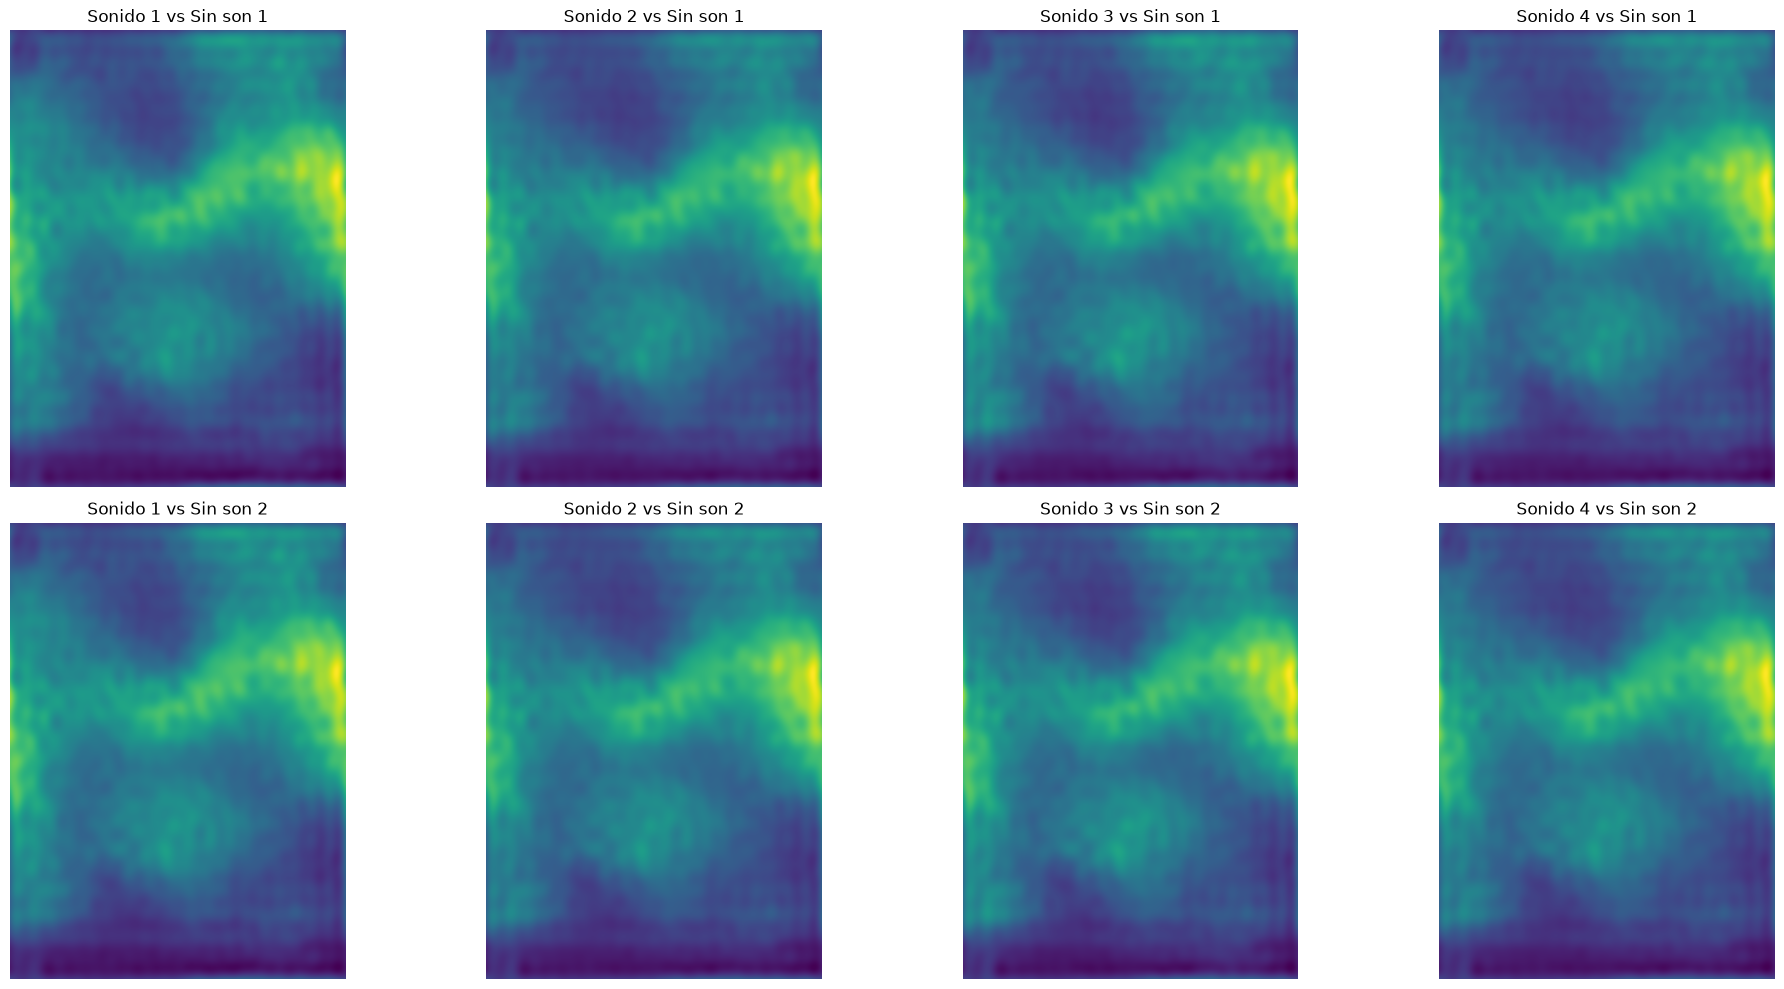

In [106]:
# radio de corte
r = 20

# Ploteado
fig, axes = plt.subplots(2, 4, figsize = (20, 10))
i , j = 0, 0
for sinj in Sin_sonido:
    for soni in Con_sonido:
        resta = operaciones_basicas.restar_consecutivas(soni, sinj)
        filtrada = filtros_en_frecuencia.filtro_pasa_bajas_frecuencia(resta, radio_corte=r)

        # Colocar la imagen en el subplot actual
        axes[j, i].imshow(filtrada, cmap='viridis') # Puedes usar cmap='gray' para blanco y negro
        
        # Opcional: Agregar un título a cada imagen
        axes[j, i].set_title(f'Sonido {i+1} vs Sin son {j+1}')
        
        # Opcional: Ocultar los ejes (líneas y números) para un aspecto más limpio
        axes[j, i].axis('off')
        i+=1
    j+=1
    i = 0

# Ajustar el espaciado automáticamente para que los títulos no se superpongan
plt.tight_layout()

# Mostrar la plantilla final
plt.show()

In [ ]:
def I(xy, k, alpha, beta, h): 
    I_final = []
    return 2 * (1 + np.cos(2 * k * (alpha * xy + (np.pi / 2 - beta) * xy + h)))

(100, 100)


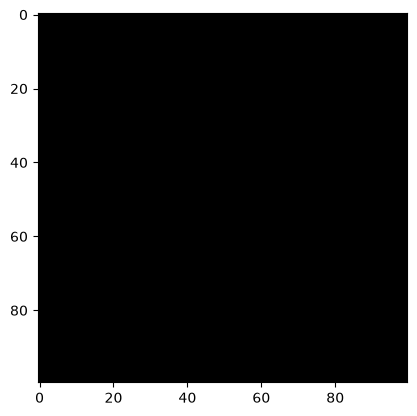

In [ ]:
lambdachiquita = 632 * 10**(-9) #nanometros
k = (2*np.pi)/lambdachiquita
alpha = 0 * 5*10**(-6)
beta = (np.pi) / (2) - 0 * 1*10**(-6)
h = 1 * lambdachiquita
sensor = [100, 100]
Intensidad = I((100, 100), k, alpha, beta, h)

print(sensor.shape)
plt.imshow(sensor, cmap='gray')
